# Dependency vs Predictive Utility vs Neural Source Importance

This section implements functional-reliance interventions. Source histories are replaced using matched donor samples while the trained forecaster is kept fixed.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc, importlib, math, random, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

warnings.filterwarnings("ignore")

SEED = 2026
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 96
LABEL_LEN = 48
ALL_HORIZONS = [96, 192, 336, 720]

CONDITIONS = [
    ("Electricity", 192),
    ("Electricity", 336),
    ("Solar", 336),
    ("Solar", 720),
    ("Weather", 720),
    ("ETTh1", 336),
    ("ETTh1", 720),
    ("ETTm1", 720),
]

MAX_TOPK = 10
RAW_CORR_TOPM = 8
TEACHER_CONSENSUS_TOPM = 12
MAX_TARGETS_HIGH_DIM = 6
MAX_TARGETS_WEATHER = 10
MAX_TRAIN_ORIGINS = 3000
MAX_TEST_WINDOWS = 256
PERTURB_SEEDS = [2026, 2027]
SOURCE_CHUNK = 8
RANK_K = 5
NUM_WORKERS = 2

PROJECT_ROOT = Path("/data/code/2026_08")
BASELINE_ROOT = PROJECT_ROOT / "results_external_baselines_phase1_direct"
TEACHER_CACHE_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_explicit_sparse_horizon_mask"
    / "predictive_teacher_hardmask_cache"
)
PREVIOUS_GROUP_PERMUTATION = (
    PROJECT_ROOT
    / "results_itransformer_channel_information_permutation"
    / "source_importance_comparison.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "results_dependency_predictive_neural_importance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def effective_topk(C):
    return int(max(1, min(MAX_TOPK, math.ceil((C - 1) / 2))))

def choose_targets(dataset_name, C):
    if C <= 10:
        return np.arange(C, dtype=np.int64)
    n = MAX_TARGETS_WEATHER if dataset_name == "Weather" else MAX_TARGETS_HIGH_DIM
    return np.unique(np.linspace(0, C - 1, min(n, C), dtype=np.int64))

def choose_batch_size(dataset_name, H):
    if dataset_name == "Electricity":
        return 8 if H >= 336 else 12
    if dataset_name == "Solar":
        return 16
    return 32

def evenly_subsample(n, max_n):
    if n <= max_n:
        return np.arange(n, dtype=np.int64)
    return np.unique(np.linspace(0, n - 1, max_n, dtype=np.int64))

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Output:", OUTPUT_DIR)

PyTorch: 2.4.1+cu121
Device: cuda
Output: /data/code/2026_08/results_dependency_predictive_neural_importance


In [2]:
# Locate Time-Series-Library
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
]

TSL_ROOT = next(
    (p.resolve() for p in TSLIB_CANDIDATES if (p / "models" / "iTransformer.py").exists()),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError("Time-Series-Library source not found.")

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(0, str(TSL_ROOT))

iTransformer_module = importlib.import_module("models.iTransformer")
print("TSLib:", TSL_ROOT)

TSLib: /data/Time-Series-Library


In [3]:
DATASET_CANDIDATES = {
    "Electricity": [
        "/data/dataset/electricity/electricity.csv",
        "/data/dataset/ECL/electricity.csv",
        "/data/dataset/electricity.csv",
    ],
    "Weather": [
        "/data/dataset/weather/weather.csv",
        "/data/dataset/weather.csv",
    ],
    "Solar": [
        "/data/dataset/solar/solar_AL.txt",
        "/data/dataset/Solar/solar_AL.txt",
        "/data/dataset/solar_AL.txt",
    ],
    "ETTh1": [
        "/data/dataset/ETT-small/ETTh1.csv",
        "/data/dataset/ETTh1.csv",
    ],
    "ETTm1": [
        "/data/dataset/ETT-small/ETTm1.csv",
        "/data/dataset/ETTm1.csv",
    ],
}

DATASET_SPECS = {
    "Electricity": {"channels": 321, "freq": "h"},
    "Weather": {"channels": 21, "freq": "t"},
    "Solar": {"channels": 137, "freq": "h"},
    "ETTh1": {"channels": 7, "freq": "h"},
    "ETTm1": {"channels": 7, "freq": "t"},
}

def resolve_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p.resolve()
    return None

DATASET_FILES = {}
for d, candidates in DATASET_CANDIDATES.items():
    path = resolve_path(candidates)
    if path is None:
        raise FileNotFoundError(f"{d}: dataset file not found.")
    DATASET_FILES[d] = path
    print(f"{d:12s} -> {path}")

def load_numeric_series(dataset_name, path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        date_col = None
        for c in ["date", "datetime", "timestamp", "time"]:
            if c in df.columns:
                date_col = c
                break
        if date_col is None:
            first = df.columns[0]
            if not pd.api.types.is_numeric_dtype(df[first]):
                date_col = first
        if date_col is not None:
            df = df.drop(columns=[date_col])
        df = df.select_dtypes(include=[np.number])
        x = df.to_numpy(dtype=np.float32)
    else:
        try:
            x = np.loadtxt(path, delimiter=",", dtype=np.float32)
        except Exception:
            x = np.loadtxt(path, dtype=np.float32)
        if x.ndim == 1:
            x = x[:, None]
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError(f"{dataset_name}: invalid data shape/content {x.shape}")
    return x

def split_boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        tr = 12 * 30 * 24
        va = tr + 4 * 30 * 24
        te = va + 4 * 30 * 24
        return min(tr, T), min(va, T), min(te, T)
    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4
        tr = 12 * unit
        va = tr + 4 * unit
        te = va + 4 * unit
        return min(tr, T), min(va, T), min(te, T)
    return int(0.70 * T), int(0.80 * T), T

def load_and_normalize(dataset_name):
    raw = load_numeric_series(dataset_name, DATASET_FILES[dataset_name])
    T, C = raw.shape
    train_end, val_end, test_end = split_boundaries(dataset_name, T)
    mean = raw[:train_end].mean(axis=0, keepdims=True)
    std = np.maximum(raw[:train_end].std(axis=0, keepdims=True), 1e-6)
    x = (raw - mean) / std
    return x.astype(np.float32), {
        "T": T, "C": C,
        "train_end": train_end,
        "val_end": val_end,
        "test_end": test_end,
    }

class ForecastDataset(Dataset):
    def __init__(self, data, pred_len, start_min, end_exclusive):
        self.data = torch.from_numpy(data).float()
        self.pred_len = int(pred_len)
        first_t = max(SEQ_LEN, LABEL_LEN, int(start_min))
        last_t = int(end_exclusive) - self.pred_len
        self.origins = np.arange(first_t, last_t + 1, dtype=np.int64)
        if len(self.origins) == 0:
            raise RuntimeError("No valid windows.")

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, idx):
        t = int(self.origins[idx])
        x = self.data[t-SEQ_LEN:t]
        y = self.data[t-LABEL_LEN:t+self.pred_len]
        return x, y

Electricity  -> /data/dataset/electricity/electricity.csv
Weather      -> /data/dataset/weather/weather.csv
Solar        -> /data/dataset/solar/solar_AL.txt
ETTh1        -> /data/dataset/ETT-small/ETTh1.csv
ETTm1        -> /data/dataset/ETT-small/ETTm1.csv


In [4]:
def build_itransformer_args(dataset_name, H):
    spec = DATASET_SPECS[dataset_name]
    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",
        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,
        enc_in=spec["channels"],
        dec_in=spec["channels"],
        c_out=spec["channels"],
        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,
        embed="timeF",
        freq=spec["freq"],
        activation="gelu",
        output_attention=False,
        class_strategy="projection",
        use_norm=1,
        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )

def build_and_load_itransformer(dataset_name, H):
    model = iTransformer_module.Model(build_itransformer_args(dataset_name, H)).float().to(DEVICE)
    checkpoint = BASELINE_ROOT / "iTransformer" / dataset_name / f"H{H}" / "best_model.pt"
    if not checkpoint.exists():
        raise FileNotFoundError(checkpoint)
    state = torch.load(checkpoint, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.eval()
    return model

In [5]:
# Training-only dependency features and teacher utilities
def common_train_origins(train_end):
    last = int(train_end) - max(ALL_HORIZONS)
    origins = np.arange(SEQ_LEN, last + 1, dtype=np.int64)
    return origins[evenly_subsample(len(origins), MAX_TRAIN_ORIGINS)]

def summary_features(x, origins):
    last = x[origins - 1]
    mean3 = np.stack([x[t-3:t].mean(axis=0) for t in origins], axis=0)
    mean12 = np.stack([x[t-12:t].mean(axis=0) for t in origins], axis=0)
    delta12 = x[origins - 1] - x[origins - 12]
    return np.stack([last, mean3, mean12, delta12], axis=-1).astype(np.float32)

def absolute_current_correlation(features):
    cur = features[:, :, 0].astype(np.float64)
    cur = cur - cur.mean(axis=0, keepdims=True)
    denom = np.maximum(np.sqrt(np.sum(cur * cur, axis=0)), 1e-12)
    z = cur / denom[None, :]
    corr = np.abs(z.T @ z)
    np.fill_diagonal(corr, 0.0)
    return corr.astype(np.float32)

def teacher_path(dataset_name, H, K):
    return TEACHER_CACHE_ROOT / f"{dataset_name}_H{H}_endpoint_predictive_topk_K{K}.npz"

def load_teacher_topk(dataset_name, H, C, K):
    path = teacher_path(dataset_name, H, K)
    if not path.exists():
        raise FileNotFoundError(path)
    c = np.load(path)
    idx = c["source_idx"].astype(np.int64)
    gain = c["source_gain"].astype(np.float32)
    if idx.shape != (C, K):
        raise RuntimeError(f"Teacher shape mismatch: {idx.shape} vs {(C,K)}")
    return idx, gain

def teacher_consensus_sources(dataset_name, C, K, topm):
    rank = {H: load_teacher_topk(dataset_name, H, C, K) for H in ALL_HORIZONS}
    result = {}
    for i in range(C):
        score, freq, gsum = {}, {}, {}
        for H in ALL_HORIZONS:
            idx, gain = rank[H]
            for r, (j, g) in enumerate(zip(idx[i].tolist(), gain[i].tolist())):
                j = int(j)
                if j == i:
                    continue
                score[j] = score.get(j, 0.0) + float(K - r)
                freq[j] = freq.get(j, 0) + 1
                gsum[j] = gsum.get(j, 0.0) + float(g)
        cand = list(score)
        cand.sort(key=lambda j: (score[j], freq[j], gsum[j]), reverse=True)
        result[i] = np.asarray(cand[:topm], dtype=np.int64)
    return result

def build_candidate_pools(dataset_name, corr, targets):
    C = corr.shape[0]
    if C <= 10:
        return {
            int(i): np.asarray([j for j in range(C) if j != i], dtype=np.int64)
            for i in targets
        }
    K = effective_topk(C)
    consensus = teacher_consensus_sources(dataset_name, C, K, TEACHER_CONSENSUS_TOPM)
    pools = {}
    for i0 in targets:
        i = int(i0)
        corr_src = [int(j) for j in np.argsort(corr[i])[::-1] if j != i][:RAW_CORR_TOPM]
        combined = []
        for j in corr_src + consensus[i].tolist():
            if j != i and j not in combined:
                combined.append(int(j))
        pools[i] = np.asarray(combined, dtype=np.int64)
    return pools

def add_bias(X):
    return np.concatenate([np.ones((len(X), 1)), X.astype(np.float64)], axis=1)

def ridge_fit(X, y, lam=1e-3):
    Xb = add_bias(X)
    reg = np.eye(Xb.shape[1], dtype=np.float64)
    reg[0, 0] = 0.0
    return np.linalg.solve(Xb.T @ Xb + lam * reg, Xb.T @ y.astype(np.float64))

def ridge_predict(X, beta):
    return add_bias(X) @ beta

def predictive_utility_for_sources(features, y, target_idx, source_ids):
    N = len(features)
    split = min(max(int(0.70 * N), 32), N - 16)
    fit = np.arange(split)
    score = np.arange(split, N)

    Xt = features[:, target_idx, :].astype(np.float64)
    U = features[:, source_ids, :].astype(np.float64)
    y = y.astype(np.float64)

    bt = ridge_fit(Xt[fit], y[fit], 1e-3)
    r_fit = y[fit] - ridge_predict(Xt[fit], bt)
    r_score = y[score] - ridge_predict(Xt[score], bt)
    base_mse = float(np.mean(r_score ** 2))

    Xf = add_bias(Xt[fit])
    Xs = add_bias(Xt[score])
    S, Fdim = U.shape[1], U.shape[2]

    Uf = U[fit].reshape(len(fit), S * Fdim)
    Us = U[score].reshape(len(score), S * Fdim)

    reg = np.eye(Xf.shape[1], dtype=np.float64)
    reg[0, 0] = 0.0
    coef = np.linalg.solve(Xf.T @ Xf + 1e-3 * reg, Xf.T @ Uf)

    Uf_res = (Uf - Xf @ coef).reshape(len(fit), S, Fdim)
    Us_res = (Us - Xs @ coef).reshape(len(score), S, Fdim)

    gram = np.einsum("nsf,nsg->sfg", Uf_res, Uf_res)
    cross = np.einsum("nsf,n->sf", Uf_res, r_fit)
    eye = np.eye(Fdim)[None, :, :]
    bs = np.linalg.solve(gram + 1e-2 * eye, cross[:, :, None])[:, :, 0]

    pred_res = np.einsum("nsf,sf->ns", Us_res, bs)
    mse = np.mean((r_score[:, None] - pred_res) ** 2, axis=0)

    return (100.0 * (base_mse - mse) / max(base_mse, 1e-12)).astype(np.float32)

In [6]:
# Test loader, latent hook, and perturbation
def prepare_sampled_test(dataset_name, H):
    x, meta = load_and_normalize(dataset_name)
    ds = ForecastDataset(x, H, meta["val_end"], meta["test_end"])
    idx = evenly_subsample(len(ds), MAX_TEST_WINDOWS)
    subset = Subset(ds, idx.tolist())
    loader = DataLoader(
        subset,
        batch_size=choose_batch_size(dataset_name, H),
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )
    return x, meta, loader, idx

class EncoderCapture:
    def __init__(self, encoder):
        self.value = None
        self.handle = encoder.register_forward_hook(self._hook)
    def _hook(self, module, inputs, output):
        self.value = (output[0] if isinstance(output, tuple) else output).detach()
    def close(self):
        self.handle.remove()

def nonzero_shift(B, seed, source_idx, batch_idx):
    if B <= 1:
        return None
    v = seed * 1000003 + int(source_idx) * 9176 + batch_idx * 131
    return 1 + (v % (B - 1))

def perturb_source_chunk(x, source_chunk, seed, batch_idx):
    B, L, C = x.shape
    S = len(source_chunk)
    aug = x[None].expand(S, B, L, C).clone()
    for q, source_idx in enumerate(source_chunk):
        j = int(source_idx)
        shift = nonzero_shift(B, seed, j, batch_idx)
        if shift is None:
            donor = torch.flip(x[:, :, j], dims=[1])
        else:
            donor_idx = torch.roll(torch.arange(B, device=x.device), shifts=shift, dims=0)
            donor = x[donor_idx, :, j]
        aug[q, :, :, j] = donor
    return aug.reshape(S * B, L, C)

In [7]:
@torch.inference_mode()
def run_condition(dataset_name, H):
    set_seed(SEED)

    x_np, meta, loader, sample_idx = prepare_sampled_test(dataset_name, H)
    C = int(meta["C"])
    targets = choose_targets(dataset_name, C)

    train_origins = common_train_origins(meta["train_end"])
    train_feat = summary_features(x_np, train_origins)
    raw_corr = absolute_current_correlation(train_feat)
    pools = build_candidate_pools(dataset_name, raw_corr, targets)

    global_sources = np.asarray(
        sorted({
            int(j)
            for i in targets
            for j in pools[int(i)]
            if int(j) != int(i)
        }),
        dtype=np.int64,
    )
    source_pos = {int(j): q for q, j in enumerate(global_sources)}

    print(
        f"{dataset_name} H={H} | C={C} | targets={len(targets)} | "
        f"sources={len(global_sources)} | test={len(sample_idx)}"
    )

    # P: predictive utility
    P = {}
    for i0 in targets:
        i = int(i0)
        src = pools[i]
        ytr = x_np[train_origins + H - 1, i]
        util = predictive_utility_for_sources(train_feat, ytr, i, src)
        P[i] = {int(j): float(u) for j, u in zip(src.tolist(), util.tolist())}

    model = build_and_load_itransformer(dataset_name, H)
    model.eval()
    cap = EncoderCapture(model.encoder)

    Tn, Sn = len(targets), len(global_sources)

    clean_full_sse = np.zeros(Tn)
    clean_end_sse = np.zeros(Tn)
    clean_full_n = np.zeros(Tn, dtype=np.int64)
    clean_end_n = np.zeros(Tn, dtype=np.int64)

    latent_sum = np.zeros((Tn, Sn))
    latent_abs_sum = np.zeros((Tn, Sn))
    latent_n = 0

    pert_full = {s: np.zeros((Tn, Sn)) for s in PERTURB_SEEDS}
    pert_end = {s: np.zeros((Tn, Sn)) for s in PERTURB_SEEDS}

    for bidx, (x, y) in enumerate(loader):
        x = x.float().to(DEVICE, non_blocking=True)
        y = y.float().to(DEVICE, non_blocking=True)
        truth = y[:, -H:, :]

        pred = model(x, None, None, None)[:, -H:, :]

        z = cap.value[:, :C, :]
        z = F.normalize(z, dim=-1)
        zt = z[:, targets, :]
        zs = z[:, global_sources, :]
        cos = torch.einsum("btd,bsd->bts", zt, zs)
        latent_sum += cos.sum(dim=0).cpu().numpy()
        latent_abs_sum += cos.abs().sum(dim=0).cpu().numpy()
        latent_n += x.shape[0]

        for tq, i0 in enumerate(targets):
            i = int(i0)
            err = pred[:, :, i] - truth[:, :, i]
            clean_full_sse[tq] += err.square().sum().item()
            clean_end_sse[tq] += err[:, -1].square().sum().item()
            clean_full_n[tq] += err.numel()
            clean_end_n[tq] += err.shape[0]

        for seed in PERTURB_SEEDS:
            for start in range(0, Sn, SOURCE_CHUNK):
                chunk = global_sources[start:start+SOURCE_CHUNK]
                x_aug = perturb_source_chunk(x, chunk, seed, bidx)
                p_aug = model(x_aug, None, None, None)[:, -H:, :]
                p_aug = p_aug.reshape(len(chunk), x.shape[0], H, C)

                for sq, j0 in enumerate(chunk):
                    sp = source_pos[int(j0)]
                    err = p_aug[sq, :, :, targets] - truth[:, :, targets]
                    pert_full[seed][:, sp] += err.square().sum(dim=(0, 1)).cpu().numpy()
                    pert_end[seed][:, sp] += err[:, -1, :].square().sum(dim=0).cpu().numpy()

                del x_aug, p_aug

        if bidx % 10 == 0:
            print(f"  batch {bidx+1}/{len(loader)}")

    cap.close()
    latent = latent_sum / max(latent_n, 1)
    latent_abs = latent_abs_sum / max(latent_n, 1)

    rows = []

    for tq, i0 in enumerate(targets):
        i = int(i0)
        clean_full_mse = clean_full_sse[tq] / clean_full_n[tq]
        clean_end_mse = clean_end_sse[tq] / clean_end_n[tq]

        for j0 in pools[i]:
            j = int(j0)
            if j == i:
                continue

            sp = source_pos[j]
            full_imp, end_imp = [], []

            for seed in PERTURB_SEEDS:
                pmse_full = pert_full[seed][tq, sp] / clean_full_n[tq]
                pmse_end = pert_end[seed][tq, sp] / clean_end_n[tq]

                full_imp.append(
                    100.0 * (pmse_full - clean_full_mse) / max(clean_full_mse, 1e-12)
                )
                end_imp.append(
                    100.0 * (pmse_end - clean_end_mse) / max(clean_end_mse, 1e-12)
                )

            rows.append({
                "dataset": dataset_name,
                "pred_len": int(H),
                "target_channel": i,
                "source_channel": j,
                "raw_abs_corr": float(raw_corr[i, j]),
                "latent_cosine": float(latent[tq, sp]),
                "latent_abs_cosine": float(latent_abs[tq, sp]),
                "predictive_utility_%": float(P[i][j]),
                "neural_full_importance_%": float(np.mean(full_imp)),
                "neural_endpoint_importance_%": float(np.mean(end_imp)),
                "neural_full_importance_seed_std": float(np.std(full_imp)),
                "neural_endpoint_importance_seed_std": float(np.std(end_imp)),
                "candidate_count": int(len(pools[i])),
                "test_windows": int(len(sample_idx)),
            })

    result = pd.DataFrame(rows)

    del model, loader, train_feat, raw_corr, pert_full, pert_end
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return result

## 3. Pre-flight

In [8]:
preflight = run_condition("ETTh1", 336)

print("Rows:", len(preflight))
display(preflight.head(10).round(4))

print(
    "Mean endpoint importance:",
    round(preflight["neural_endpoint_importance_%"].mean(), 4)
)
print(
    "Mean perturb-seed std:",
    round(preflight["neural_endpoint_importance_seed_std"].mean(), 4)
)
print("Pre-flight: PASSED")

ETTh1 H=336 | C=7 | targets=7 | sources=7 | test=256
  batch 1/8
Rows: 42


,dataset,pred_len,target_channel,source_channel,raw_abs_corr,latent_cosine,latent_abs_cosine,predictive_utility_%,neural_full_importance_%,neural_endpoint_importance_%,neural_full_importance_seed_std,neural_endpoint_importance_seed_std,candidate_count,test_windows
0,ETTh1,336,0,1,0.2878,0.2378,0.3970,-0.1470,-0.2716,-0.2282,0.0491,0.0884,6,256
1,ETTh1,336,0,2,0.9819,0.9913,0.9913,2.6602,0.8931,1.1158,0.0195,0.4080,6,256
2,ETTh1,336,0,3,0.2121,0.2250,0.3842,0.2657,-0.2610,-0.1949,0.0988,0.2989,6,256
3,ETTh1,336,0,4,0.4383,0.2609,0.3040,3.0604,0.0058,-1.1419,0.0532,0.0744,6,256
4,ETTh1,336,0,5,0.0919,-0.1205,0.3013,0.3770,0.2677,0.2182,0.0004,0.1755,6,256
5,ETTh1,336,0,6,0.2343,-0.0927,0.2069,-10.9257,1.0792,1.4289,0.0907,0.3111,6,256
6,ETTh1,336,1,0,0.2878,0.2378,0.3970,-28.4360,-0.1346,0.4799,0.0284,0.1010,6,256
7,ETTh1,336,1,2,0.2552,0.2470,0.4035,-29.1646,-0.2718,0.4770,0.0456,0.1212,6,256
8,ETTh1,336,1,3,0.9404,0.9777,0.9777,-3.0950,0.8817,0.7051,0.2106,0.5175,6,256
9,ETTh1,336,1,4,0.2328,-0.0272,0.2868,-3.5019,0.4142,0.5772,0.0774,0.2551,6,256


Mean endpoint importance: 0.21
Mean perturb-seed std: 0.2583
Pre-flight: PASSED


## 4. Run all conditions with resume

In [9]:
all_frames = []
failures = []

for dataset_name, H in CONDITIONS:
    print("\n" + "=" * 90)
    print(f"{dataset_name} H={H}")
    print("=" * 90)

    path = OUTPUT_DIR / f"{dataset_name}_H{H}_pair_scores.csv"

    if path.exists():
        print("Reusing completed condition.")
        all_frames.append(pd.read_csv(path))
        continue

    try:
        df = run_condition(dataset_name, H)
        df.to_csv(path, index=False)
        all_frames.append(df)
    except Exception as e:
        failures.append({
            "dataset": dataset_name,
            "pred_len": H,
            "error": repr(e),
        })
        print("FAILED:", repr(e))

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

if not all_frames:
    raise RuntimeError("No completed conditions.")

pairs_all = pd.concat(all_frames, ignore_index=True)
pairs_all.to_csv(OUTPUT_DIR / "pair_scores_all.csv", index=False)
pd.DataFrame(failures).to_csv(OUTPUT_DIR / "failures.csv", index=False)

print(
    "Completed conditions:",
    pairs_all[["dataset", "pred_len"]].drop_duplicates().shape[0],
)
print("Pair rows:", len(pairs_all))
print("Failures:", len(failures))


Electricity H=192
Electricity H=192 | C=321 | targets=6 | sources=93 | test=256
  batch 1/22
  batch 11/22
  batch 21/22

Electricity H=336
Electricity H=336 | C=321 | targets=6 | sources=93 | test=256
  batch 1/32
  batch 11/32
  batch 21/32
  batch 31/32

Solar H=336
Solar H=336 | C=137 | targets=6 | sources=60 | test=256
  batch 1/16
  batch 11/16

Solar H=720
Solar H=720 | C=137 | targets=6 | sources=60 | test=256
  batch 1/16
  batch 11/16

Weather H=720
Weather H=720 | C=21 | targets=10 | sources=21 | test=256
  batch 1/8

ETTh1 H=336
ETTh1 H=336 | C=7 | targets=7 | sources=7 | test=256
  batch 1/8

ETTh1 H=720
ETTh1 H=720 | C=7 | targets=7 | sources=7 | test=256
  batch 1/8

ETTm1 H=720
ETTm1 H=720 | C=7 | targets=7 | sources=7 | test=256
  batch 1/8
Completed conditions: 8
Pair rows: 737
Failures: 0


## 5. Rank metrics and target-level alignment

In [10]:
def safe_spearman(a, b):
    s = pd.DataFrame({"a": a, "b": b}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 3 or s["a"].nunique() < 2 or s["b"].nunique() < 2:
        return np.nan
    return float(s.corr(method="spearman").iloc[0, 1])

def topk_ids(scores, ids, k):
    order = np.argsort(np.asarray(scores, dtype=np.float64))[::-1][:k]
    return set(np.asarray(ids, dtype=np.int64)[order].tolist())

def topk_jaccard(a, b, ids, k):
    A = topk_ids(a, ids, k)
    B = topk_ids(b, ids, k)
    return len(A & B) / max(1, len(A | B))

def topk_recall(pred, rel, ids, k):
    P = topk_ids(pred, ids, k)
    T = topk_ids(rel, ids, k)
    return len(P & T) / max(1, len(T))

def ndcg_at_k(rank_scores, relevance_scores, k):
    rank_scores = np.asarray(rank_scores, dtype=np.float64)
    rel = np.maximum(np.asarray(relevance_scores, dtype=np.float64), 0.0)
    if np.all(rel <= 0):
        return np.nan

    order = np.argsort(rank_scores)[::-1][:k]
    ideal = np.argsort(rel)[::-1][:k]

    def dcg(sel):
        vals = rel[sel]
        disc = 1.0 / np.log2(np.arange(2, 2 + len(vals)))
        # Linear relevance avoids overflow when importance percentages are large.
        return float(np.sum(vals * disc))

    denom = dcg(ideal)
    return np.nan if denom <= 0 else dcg(order) / denom

rows = []

for (dataset, H, target), sub in pairs_all.groupby(
    ["dataset", "pred_len", "target_channel"]
):
    ids = sub["source_channel"].to_numpy()
    P = sub["predictive_utility_%"].to_numpy()
    I = sub["neural_endpoint_importance_%"].to_numpy()
    Araw = sub["raw_abs_corr"].to_numpy()
    Alat = sub["latent_abs_cosine"].to_numpy()
    k = min(RANK_K, len(sub))

    rows.append({
        "dataset": dataset,
        "pred_len": int(H),
        "target_channel": int(target),
        "n_sources": len(sub),
        "rank_k": k,

        "rho_P_I": safe_spearman(P, I),
        "rho_Araw_I": safe_spearman(Araw, I),
        "rho_Alatent_I": safe_spearman(Alat, I),

        "rho_Araw_P": safe_spearman(Araw, P),
        "rho_Alatent_P": safe_spearman(Alat, P),

        "jaccard_P_I": topk_jaccard(P, I, ids, k),
        "jaccard_Araw_I": topk_jaccard(Araw, I, ids, k),
        "jaccard_Alatent_I": topk_jaccard(Alat, I, ids, k),

        "recall_P_to_I": topk_recall(P, I, ids, k),
        "recall_Araw_to_I": topk_recall(Araw, I, ids, k),
        "recall_Alatent_to_I": topk_recall(Alat, I, ids, k),

        "ndcg_P_to_I": ndcg_at_k(P, I, k),
        "ndcg_Araw_to_I": ndcg_at_k(Araw, I, k),
        "ndcg_Alatent_to_I": ndcg_at_k(Alat, I, k),

        "mean_neural_importance_%": float(np.mean(I)),
        "positive_neural_source_fraction": float(np.mean(I > 0)),
        "mean_importance_seed_std": float(
            sub["neural_endpoint_importance_seed_std"].mean()
        ),
    })

target_alignment = pd.DataFrame(rows)
target_alignment.to_csv(OUTPUT_DIR / "target_alignment.csv", index=False)

display(target_alignment.head(20).round(3))

,dataset,pred_len,target_channel,n_sources,rank_k,rho_P_I,rho_Araw_I,rho_Alatent_I,rho_Araw_P,rho_Alatent_P,...,jaccard_Alatent_I,recall_P_to_I,recall_Araw_to_I,recall_Alatent_to_I,ndcg_P_to_I,ndcg_Araw_to_I,ndcg_Alatent_to_I,mean_neural_importance_%,positive_neural_source_fraction,mean_importance_seed_std
0,ETTh1,336,0,6,5,-0.429,-0.143,-0.257,0.429,0.314,...,0.667,0.8,0.8,0.8,0.363,0.772,0.535,0.200,0.500,0.226
1,ETTh1,336,1,6,5,-0.029,-0.086,0.486,0.600,-0.371,...,1.000,0.8,0.8,1.0,0.839,0.895,0.982,0.496,1.000,0.243
2,ETTh1,336,2,6,5,-0.371,-0.314,-0.086,-0.143,0.143,...,0.667,0.8,0.8,0.8,0.218,0.650,0.411,0.183,0.500,0.238
3,ETTh1,336,3,6,5,0.486,-0.429,-0.600,0.429,-0.314,...,0.667,1.0,0.8,0.8,0.876,0.723,0.741,0.307,1.000,0.402
4,ETTh1,336,4,6,5,0.943,0.257,-0.429,0.486,-0.257,...,0.667,1.0,1.0,0.8,0.993,0.646,0.517,0.082,0.667,0.305
5,ETTh1,336,5,6,5,-0.543,-0.371,-0.771,0.143,0.771,...,0.667,0.8,0.8,0.8,0.559,0.540,0.466,0.089,0.667,0.286
6,ETTh1,336,6,6,5,0.771,1.000,0.543,0.771,0.771,...,1.000,1.0,1.0,1.0,0.955,1.000,0.868,0.113,0.500,0.108
7,ETTh1,720,0,6,5,-0.429,-0.029,-0.257,0.714,0.829,...,0.667,0.8,0.8,0.8,0.415,0.647,0.433,1.186,0.667,0.852
8,ETTh1,720,1,6,5,0.086,0.086,0.429,0.429,0.486,...,1.000,0.8,0.8,1.0,0.794,0.901,0.895,-0.108,0.500,0.254
9,ETTh1,720,2,6,5,-0.371,-0.257,0.086,0.714,0.600,...,0.667,0.8,0.8,0.8,0.428,0.619,0.466,1.302,0.833,0.795


## 6. Condition and global summaries

In [11]:
condition_alignment = (
    target_alignment
    .groupby(["dataset", "pred_len"], as_index=False)
    .agg(
        targets=("target_channel", "size"),
        median_rho_P_I=("rho_P_I", "median"),
        median_rho_Araw_I=("rho_Araw_I", "median"),
        median_rho_Alatent_I=("rho_Alatent_I", "median"),
        mean_jaccard_P_I=("jaccard_P_I", "mean"),
        mean_jaccard_Araw_I=("jaccard_Araw_I", "mean"),
        mean_jaccard_Alatent_I=("jaccard_Alatent_I", "mean"),
        mean_recall_P_to_I=("recall_P_to_I", "mean"),
        mean_recall_Araw_to_I=("recall_Araw_to_I", "mean"),
        mean_recall_Alatent_to_I=("recall_Alatent_to_I", "mean"),
        mean_ndcg_P_to_I=("ndcg_P_to_I", "mean"),
        mean_ndcg_Araw_to_I=("ndcg_Araw_to_I", "mean"),
        mean_ndcg_Alatent_to_I=("ndcg_Alatent_to_I", "mean"),
        mean_neural_importance=("mean_neural_importance_%", "mean"),
        mean_importance_seed_std=("mean_importance_seed_std", "mean"),
    )
)

condition_alignment.to_csv(
    OUTPUT_DIR / "condition_alignment_summary.csv",
    index=False,
)

display(condition_alignment.round(3))

global_alignment = pd.DataFrame([
    {
        "signal": "Predictive Utility",
        "median_spearman_to_neural": target_alignment["rho_P_I"].median(),
        "mean_topk_jaccard": target_alignment["jaccard_P_I"].mean(),
        "mean_topk_recall": target_alignment["recall_P_to_I"].mean(),
        "mean_ndcg": target_alignment["ndcg_P_to_I"].mean(),
    },
    {
        "signal": "Raw Dependency",
        "median_spearman_to_neural": target_alignment["rho_Araw_I"].median(),
        "mean_topk_jaccard": target_alignment["jaccard_Araw_I"].mean(),
        "mean_topk_recall": target_alignment["recall_Araw_to_I"].mean(),
        "mean_ndcg": target_alignment["ndcg_Araw_to_I"].mean(),
    },
    {
        "signal": "Latent Dependency",
        "median_spearman_to_neural": target_alignment["rho_Alatent_I"].median(),
        "mean_topk_jaccard": target_alignment["jaccard_Alatent_I"].mean(),
        "mean_topk_recall": target_alignment["recall_Alatent_to_I"].mean(),
        "mean_ndcg": target_alignment["ndcg_Alatent_to_I"].mean(),
    },
])

global_alignment.to_csv(
    OUTPUT_DIR / "global_alignment_summary.csv",
    index=False,
)

display(global_alignment.round(3))

,dataset,pred_len,targets,median_rho_P_I,median_rho_Araw_I,median_rho_Alatent_I,mean_jaccard_P_I,mean_jaccard_Araw_I,mean_jaccard_Alatent_I,mean_recall_P_to_I,mean_recall_Araw_to_I,mean_recall_Alatent_to_I,mean_ndcg_P_to_I,mean_ndcg_Araw_to_I,mean_ndcg_Alatent_to_I,mean_neural_importance,mean_importance_seed_std
0,ETTh1,336,7,-0.029,-0.143,-0.257,0.810,0.762,0.762,0.886,0.857,0.857,0.686,0.747,0.646,0.210,0.258
1,ETTh1,720,7,-0.371,-0.086,-0.086,0.667,0.667,0.762,0.800,0.800,0.857,0.537,0.730,0.637,0.368,0.504
2,ETTm1,720,7,-0.314,0.429,0.029,0.667,0.762,0.810,0.800,0.857,0.886,0.489,0.665,0.524,0.857,0.883
3,Electricity,192,6,0.153,-0.134,0.064,0.210,0.139,0.181,0.333,0.233,0.300,0.322,0.345,0.438,0.029,0.325
4,Electricity,336,6,-0.203,0.088,-0.039,0.093,0.222,0.217,0.167,0.333,0.333,0.192,0.383,0.395,0.127,0.600
5,Solar,336,6,-0.068,0.083,0.024,0.111,0.139,0.144,0.200,0.233,0.233,0.494,0.465,0.487,4.612,3.066
6,Solar,720,6,-0.146,0.051,0.042,0.093,0.316,0.286,0.167,0.467,0.433,0.594,0.711,0.707,8.783,2.887
7,Weather,720,10,0.036,0.081,0.277,0.119,0.269,0.335,0.200,0.400,0.480,0.237,0.527,0.601,0.048,0.453


,signal,median_spearman_to_neural,mean_topk_jaccard,mean_topk_recall,mean_ndcg
0,Predictive Utility,-0.125,0.350,0.447,0.436
1,Raw Dependency,0.022,0.417,0.531,0.576
2,Latent Dependency,0.029,0.448,0.560,0.560


## 7. Cross-horizon ranking stability

In [12]:
hrows = []

for dataset, subd in pairs_all.groupby("dataset"):
    horizons = sorted(subd["pred_len"].unique())
    if len(horizons) < 2:
        continue

    for a in range(len(horizons)):
        for b in range(a + 1, len(horizons)):
            H1, H2 = horizons[a], horizons[b]

            m = subd[subd["pred_len"] == H1].merge(
                subd[subd["pred_len"] == H2],
                on=["dataset", "target_channel", "source_channel"],
                suffixes=("_H1", "_H2"),
            )

            for target, st in m.groupby("target_channel"):
                ids = st["source_channel"].to_numpy()
                P1 = st["predictive_utility_%_H1"].to_numpy()
                P2 = st["predictive_utility_%_H2"].to_numpy()
                I1 = st["neural_endpoint_importance_%_H1"].to_numpy()
                I2 = st["neural_endpoint_importance_%_H2"].to_numpy()
                L1 = st["latent_abs_cosine_H1"].to_numpy()
                L2 = st["latent_abs_cosine_H2"].to_numpy()
                k = min(RANK_K, len(st))

                hrows.append({
                    "dataset": dataset,
                    "H1": int(H1),
                    "H2": int(H2),
                    "target_channel": int(target),

                    "rho_P_H1_H2": safe_spearman(P1, P2),
                    "rho_I_H1_H2": safe_spearman(I1, I2),
                    "rho_Latent_H1_H2": safe_spearman(L1, L2),

                    "jaccard_P_H1_H2": topk_jaccard(P1, P2, ids, k),
                    "jaccard_I_H1_H2": topk_jaccard(I1, I2, ids, k),
                    "jaccard_Latent_H1_H2": topk_jaccard(L1, L2, ids, k),
                })

horizon_target = pd.DataFrame(hrows)

if len(horizon_target):
    horizon_summary = (
        horizon_target
        .groupby(["dataset", "H1", "H2"], as_index=False)
        .agg(
            targets=("target_channel", "size"),
            median_rho_P=("rho_P_H1_H2", "median"),
            median_rho_I=("rho_I_H1_H2", "median"),
            median_rho_Latent=("rho_Latent_H1_H2", "median"),
            mean_jaccard_P=("jaccard_P_H1_H2", "mean"),
            mean_jaccard_I=("jaccard_I_H1_H2", "mean"),
            mean_jaccard_Latent=("jaccard_Latent_H1_H2", "mean"),
        )
    )

    horizon_target.to_csv(
        OUTPUT_DIR / "horizon_drift_target.csv",
        index=False,
    )
    horizon_summary.to_csv(
        OUTPUT_DIR / "horizon_drift_summary.csv",
        index=False,
    )
    display(horizon_summary.round(3))
else:
    horizon_summary = pd.DataFrame()
    print("No paired horizons.")

,dataset,H1,H2,targets,median_rho_P,median_rho_I,median_rho_Latent,mean_jaccard_P,mean_jaccard_I,mean_jaccard_Latent
0,ETTh1,336,720,7,0.714,0.771,0.771,0.905,0.857,1.000
1,Electricity,192,336,6,0.699,-0.135,0.993,0.339,0.120,0.833
2,Solar,336,720,6,0.417,-0.192,0.936,0.116,0.097,0.643


## 8. Optional connection to previous grouped permutation

In [13]:
if PREVIOUS_GROUP_PERMUTATION.exists():
    prev = pd.read_csv(PREVIOUS_GROUP_PERMUTATION)

    keep = [
        c for c in [
            "dataset",
            "pred_len",
            "adaptive_minus_random_endpoint_pp",
            "adaptive_minus_shared_endpoint_pp",
            "AllOtherChannels_endpoint",
        ]
        if c in prev.columns
    ]

    joined = condition_alignment.merge(
        prev[keep],
        on=["dataset", "pred_len"],
        how="left",
        validate="one_to_one",
    )

    joined.to_csv(
        OUTPUT_DIR / "connection_to_group_permutation.csv",
        index=False,
    )

    display(joined.round(3))
else:
    print("Previous grouped permutation summary not found.")

,dataset,pred_len,targets,median_rho_P_I,median_rho_Araw_I,median_rho_Alatent_I,mean_jaccard_P_I,mean_jaccard_Araw_I,mean_jaccard_Alatent_I,mean_recall_P_to_I,mean_recall_Araw_to_I,mean_recall_Alatent_to_I,mean_ndcg_P_to_I,mean_ndcg_Araw_to_I,mean_ndcg_Alatent_to_I,mean_neural_importance,mean_importance_seed_std,adaptive_minus_random_endpoint_pp,adaptive_minus_shared_endpoint_pp,AllOtherChannels_endpoint
0,ETTh1,336,7,-0.029,-0.143,-0.257,0.810,0.762,0.762,0.886,0.857,0.857,0.686,0.747,0.646,0.210,0.258,-0.370,0.317,1.869
1,ETTh1,720,7,-0.371,-0.086,-0.086,0.667,0.667,0.762,0.800,0.800,0.857,0.537,0.730,0.637,0.368,0.504,-3.431,0.040,4.008
2,ETTm1,720,7,-0.314,0.429,0.029,0.667,0.762,0.810,0.800,0.857,0.886,0.489,0.665,0.524,0.857,0.883,-1.538,-0.836,1.671
3,Electricity,192,6,0.153,-0.134,0.064,0.210,0.139,0.181,0.333,0.233,0.300,0.322,0.345,0.438,0.029,0.325,0.288,-0.004,53.315
4,Electricity,336,6,-0.203,0.088,-0.039,0.093,0.222,0.217,0.167,0.333,0.333,0.192,0.383,0.395,0.127,0.600,0.910,0.009,7.750
5,Solar,336,6,-0.068,0.083,0.024,0.111,0.139,0.144,0.200,0.233,0.233,0.494,0.465,0.487,4.612,3.066,1.731,-0.442,17.538
6,Solar,720,6,-0.146,0.051,0.042,0.093,0.316,0.286,0.167,0.467,0.433,0.594,0.711,0.707,8.783,2.887,-0.534,-2.378,19.412
7,Weather,720,10,0.036,0.081,0.277,0.119,0.269,0.335,0.200,0.400,0.480,0.237,0.527,0.601,0.048,0.453,0.296,-0.071,-0.227


## 9. Plots

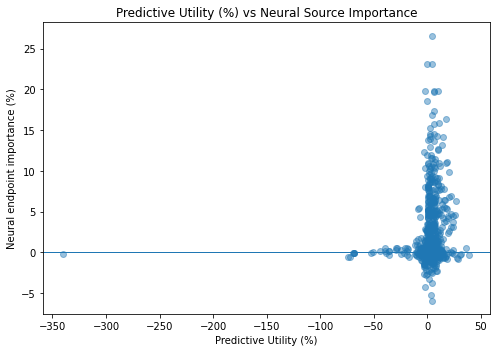

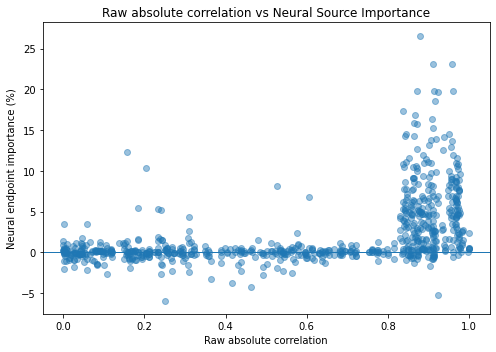

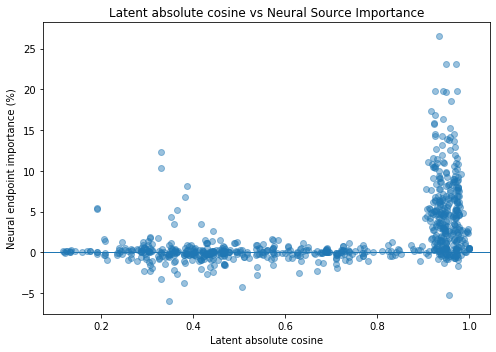

In [14]:
# Self-contained plotting cell.
import matplotlib.pyplot as plt

for x_col, x_label in [
    ("predictive_utility_%", "Predictive Utility (%)"),
    ("raw_abs_corr", "Raw absolute correlation"),
    ("latent_abs_cosine", "Latent absolute cosine"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        pairs_all[x_col],
        pairs_all["neural_endpoint_importance_%"],
        alpha=0.45,
    )
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Neural endpoint importance (%)")
    ax.set_title(f"{x_label} vs Neural Source Importance")
    plt.tight_layout()
    plt.show()

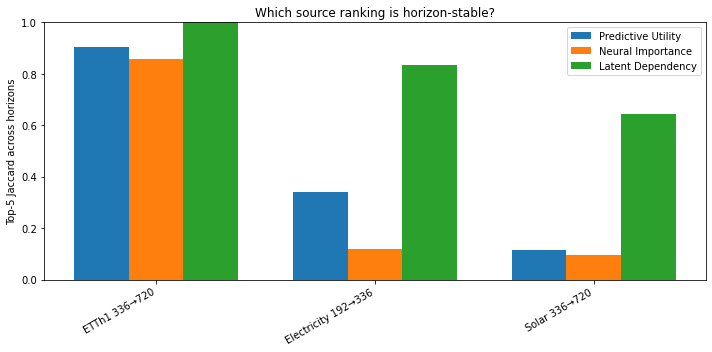

In [15]:
# Self-contained plotting cell.
import matplotlib.pyplot as plt

if len(horizon_summary):
    labels = (
        horizon_summary["dataset"]
        + " "
        + horizon_summary["H1"].astype(str)
        + "→"
        + horizon_summary["H2"].astype(str)
    )

    x = np.arange(len(horizon_summary))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        x - width,
        horizon_summary["mean_jaccard_P"],
        width,
        label="Predictive Utility",
    )
    ax.bar(
        x,
        horizon_summary["mean_jaccard_I"],
        width,
        label="Neural Importance",
    )
    ax.bar(
        x + width,
        horizon_summary["mean_jaccard_Latent"],
        width,
        label="Latent Dependency",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel(f"Top-{RANK_K} Jaccard across horizons")
    ax.set_ylim(0, 1)
    ax.set_title("Which source ranking is horizon-stable?")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 10. Automatic interpretation

In [16]:
median_P_I = float(target_alignment["rho_P_I"].median())
median_Araw_I = float(target_alignment["rho_Araw_I"].median())
median_Alatent_I = float(target_alignment["rho_Alatent_I"].median())

ndcg_P = float(target_alignment["ndcg_P_to_I"].mean())
ndcg_Araw = float(target_alignment["ndcg_Araw_to_I"].mean())
ndcg_Alatent = float(target_alignment["ndcg_Alatent_to_I"].mean())

print("=" * 88)
print("DEPENDENCY vs PREDICTIVE UTILITY vs NEURAL IMPORTANCE")
print("=" * 88)

print("\nMedian Spearman to Neural Importance")
print(f"  Predictive Utility : {median_P_I:+.3f}")
print(f"  Raw Dependency     : {median_Araw_I:+.3f}")
print(f"  Latent Dependency  : {median_Alatent_I:+.3f}")

print("\nMean NDCG@K to Neural Importance")
print(f"  Predictive Utility : {ndcg_P:.3f}")
print(f"  Raw Dependency     : {ndcg_Araw:.3f}")
print(f"  Latent Dependency  : {ndcg_Alatent:.3f}")

if (
    median_P_I > 0.30
    and ndcg_P > max(ndcg_Araw, ndcg_Alatent)
):
    print(
        "\nA. Predictive Utility aligns substantially with neural reliance."
    )
    print(
        "Earlier routing failures are then better explained by "
        "topology imposition/utilization rather than source identification."
    )

elif max(median_Araw_I, median_Alatent_I) > median_P_I + 0.10:
    print(
        "\nB. Neural reliance aligns better with dependency/representation "
        "than with Ridge Predictive Utility."
    )
    print(
        "This supports model-dependent source utility."
    )

else:
    print(
        "\nC. No simple static pairwise signal strongly explains neural reliance."
    )
    print(
        "The strong model may exploit distributed or context-dependent "
        "cross-channel information."
    )

if len(horizon_summary):
    jp = float(horizon_summary["mean_jaccard_P"].mean())
    ji = float(horizon_summary["mean_jaccard_I"].mean())
    jl = float(horizon_summary["mean_jaccard_Latent"].mean())

    print("\nCross-horizon Top-K Jaccard")
    print(f"  Predictive Utility : {jp:.3f}")
    print(f"  Neural Importance  : {ji:.3f}")
    print(f"  Latent Dependency  : {jl:.3f}")

    if ji > jp + 0.10:
        print(
            "\nNeural source importance is more horizon-stable than "
            "Predictive Utility."
        )
        print(
            "This directly supports why SharedSparse can match or beat "
            "HorizonAdaptiveSparse in the strong backbone."
        )

print("\nDo not design another router from this result.")

DEPENDENCY vs PREDICTIVE UTILITY vs NEURAL IMPORTANCE

Median Spearman to Neural Importance
  Predictive Utility : -0.125
  Raw Dependency     : +0.022
  Latent Dependency  : +0.029

Mean NDCG@K to Neural Importance
  Predictive Utility : 0.436
  Raw Dependency     : 0.576
  Latent Dependency  : 0.560

B. Neural reliance aligns better with dependency/representation than with Ridge Predictive Utility.
This supports model-dependent source utility.

Cross-horizon Top-K Jaccard
  Predictive Utility : 0.453
  Neural Importance  : 0.358
  Latent Dependency  : 0.825

Do not design another router from this result.


This section implements functional-reliance interventions. Source histories are replaced using matched donor samples while the trained forecaster is kept fixed.
